In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [2]:
#Load dataset
df = pd.read_csv('../data/raw-data.csv')

#Cek beberapa baris pertama dari dataset
print("Beberapa baris pertama dari dataset:")
print(df.head())

#Cek rangkuman statistik dari dataset
print ("Rangkuman statistik dataset:")
print(df.describe(include='all'))


Beberapa baris pertama dari dataset:
   Country  Year        Attack Type     Target Industry  \
0    China  2019           Phishing           Education   
1    China  2019         Ransomware              Retail   
2    India  2017  Man-in-the-Middle                  IT   
3       UK  2024         Ransomware  Telecommunications   
4  Germany  2018  Man-in-the-Middle                  IT   

   Financial Loss (in Million $)  Number of Affected Users Attack Source  \
0                          80.53                    773169  Hacker Group   
1                          62.19                    295961  Hacker Group   
2                          38.65                    605895  Hacker Group   
3                          41.44                    659320  Nation-state   
4                          74.41                    810682       Insider   

  Security Vulnerability Type Defense Mechanism Used  \
0          Unpatched Software                    VPN   
1          Unpatched Software          

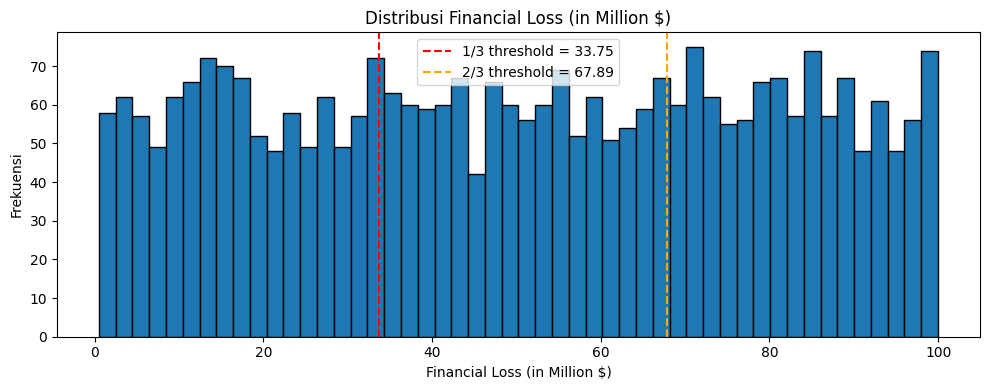

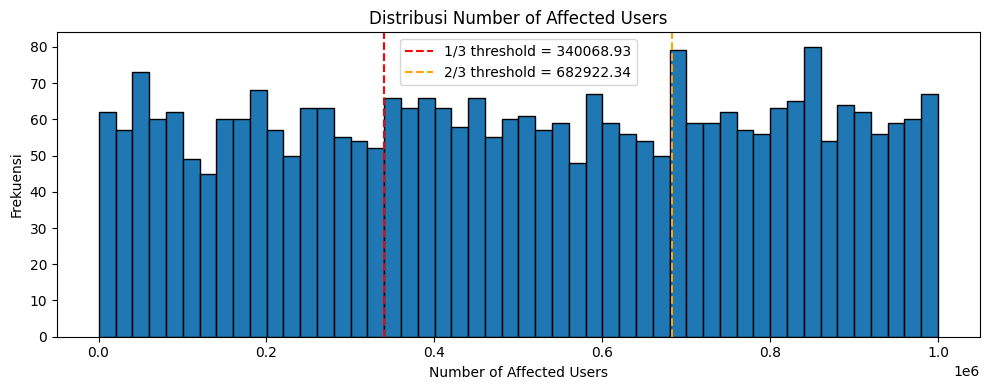

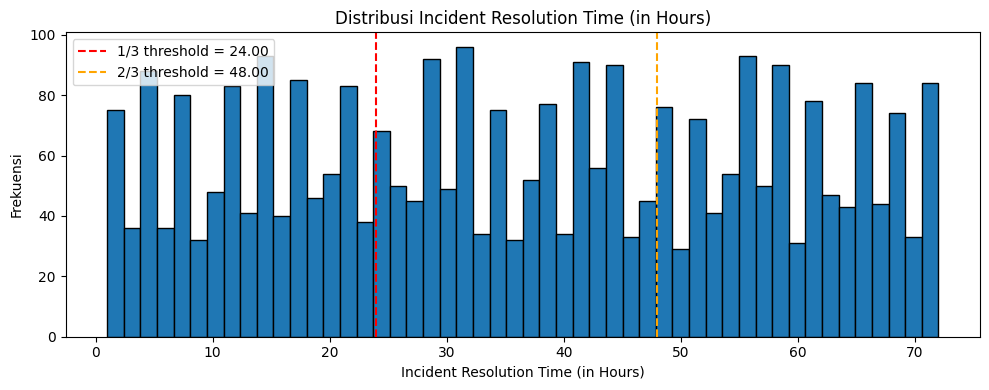

In [3]:
# Cek distribusi financial loss, number of affected users, dan incident resolution time
col_names = ['Financial Loss (in Million $)', 'Number of Affected Users', 'Incident Resolution Time (in Hours)']

for col in col_names:
    # Hitung threshold di 1/3 dan 2/3 distribusi
    t1 = df[col].quantile(0.33)
    t2 = df[col].quantile(0.67)
    
    # Plot distribusi
    plt.figure(figsize=(10, 4))
    plt.hist(df[col], bins=50, edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.title(f'Distribusi {col}')
    plt.axvline(x=t1, color='red', linestyle='--', label=f'1/3 threshold = {t1:.2f}')
    plt.axvline(x=t2, color='orange', linestyle='--', label=f'2/3 threshold = {t2:.2f}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"Distribusi {col}.png", dpi=300, bbox_inches='tight')
    plt.show()

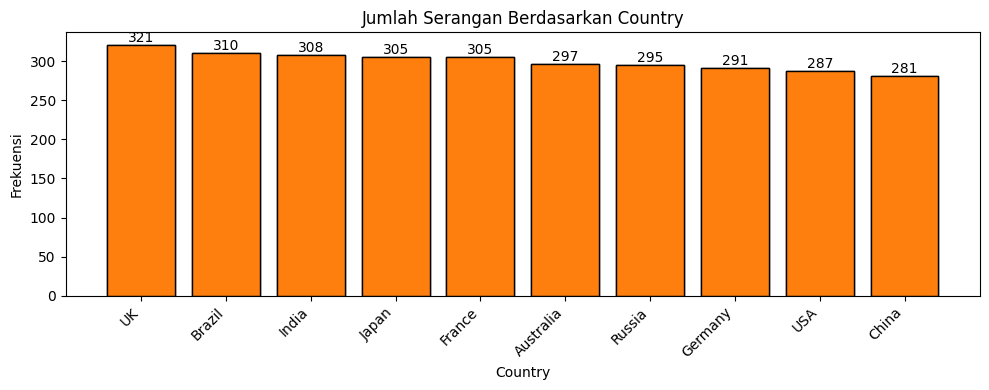

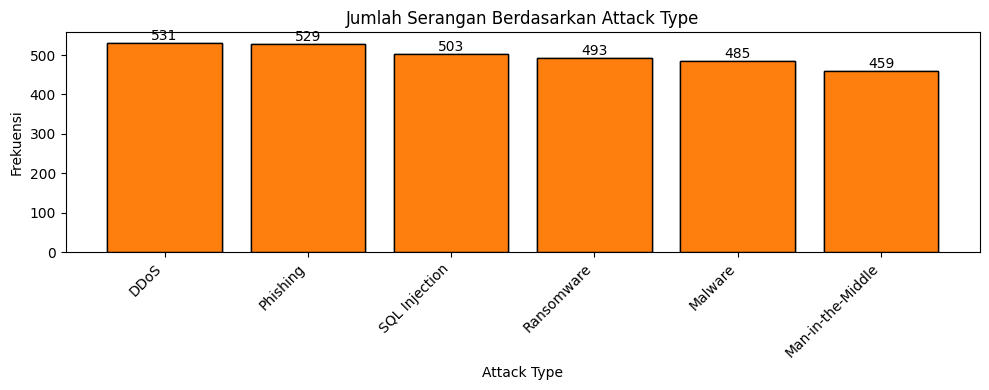

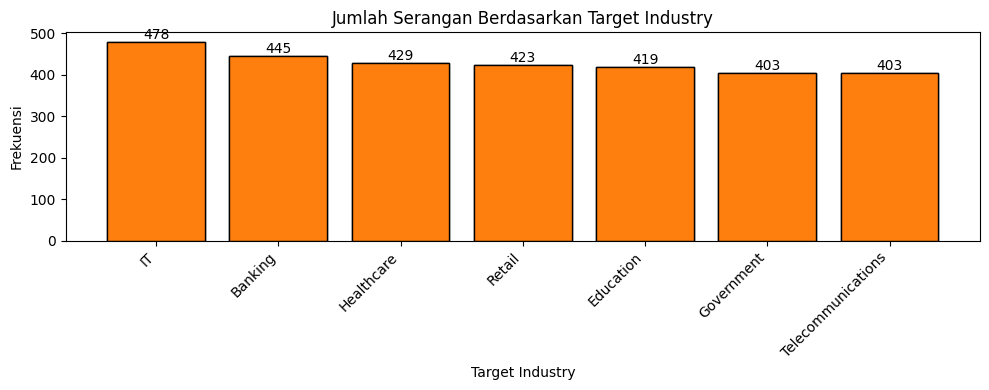

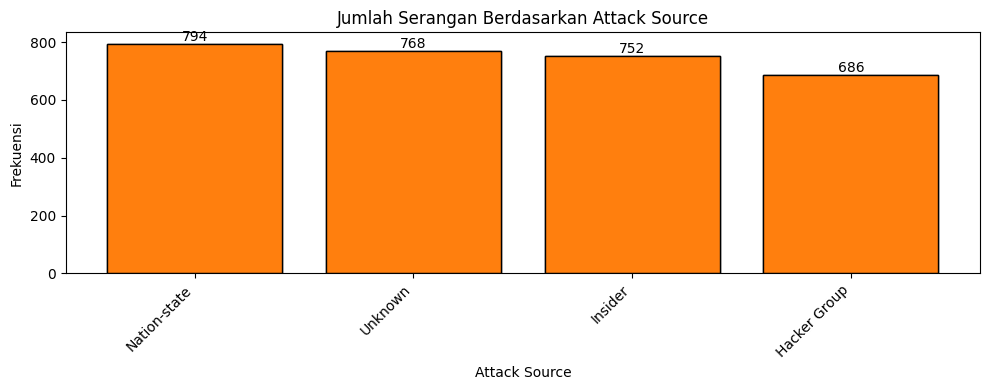

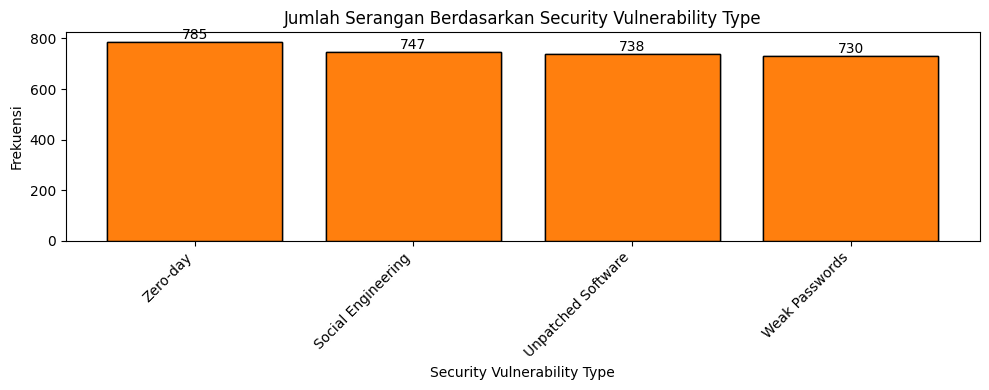

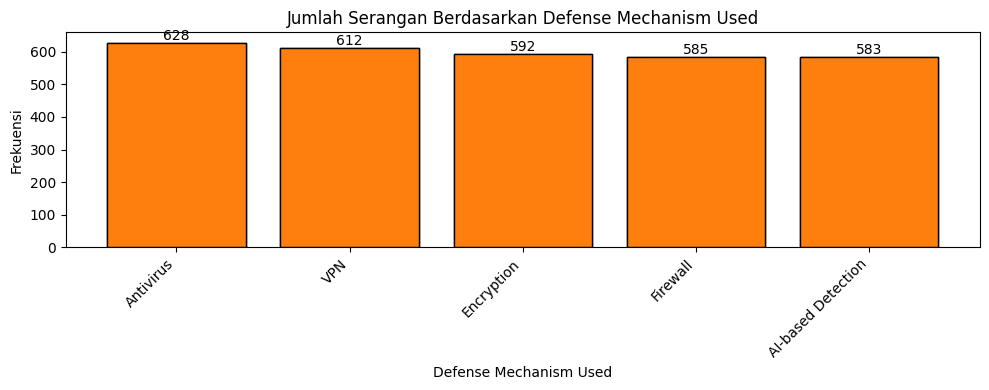

In [4]:
#Cek distribusi kolom kategori
cat_cols = ['Country','Attack Type','Target Industry', 'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used']
for col in cat_cols:

    #Hitung frekuensi
    counts = df[col].value_counts().sort_values(ascending=False) 
    
    # Plot distribusi
    plt.figure(figsize=(10, 4))
    plt.bar(counts.index, counts.values, edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.title(f'Jumlah Serangan Berdasarkan {col}')
    plt.xticks(rotation=45, ha='right')
    bars = plt.bar(counts.index, counts.values, edgecolor='black')
    plt.bar_label(bars)
    plt.tight_layout()
    plt.savefig(f"Jumlah Serangan Berdasarkan {col}.png", dpi=300, bbox_inches='tight')
    plt.show()

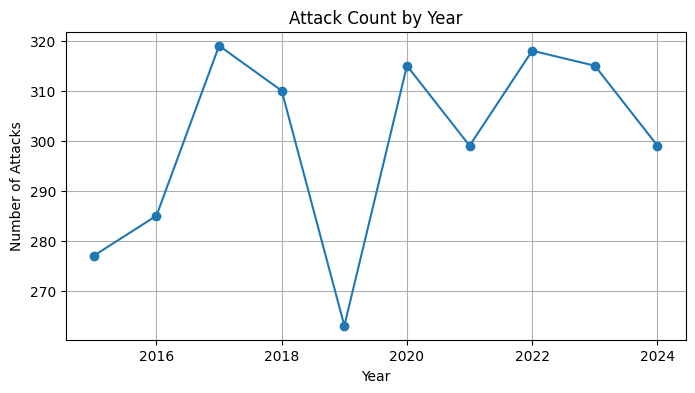

In [5]:
year_counts = df['Year'].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.plot(year_counts.index, year_counts.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.title('Attack Count by Year')
plt.grid(True)
plt.savefig(f"Time Series of Attack Count.png", dpi=300, bbox_inches='tight')
plt.show()

In [6]:
#Menentukan impact score
scaler = MinMaxScaler()
cols_impact = ['Financial Loss (in Million $)', 
               'Number of Affected Users', 
               'Incident Resolution Time (in Hours)']

df_scaled = df.copy()
df_scaled[cols_impact] = scaler.fit_transform(df[cols_impact])

# Impact score = rata-rata tertimbang ketiganya
# Bisa beri bobot berbeda kalau mau, ini equal weight dulu
df_scaled['impact_score'] = (
    df_scaled['Financial Loss (in Million $)'] * 0.5 +
    df_scaled['Number of Affected Users'] * 0.3 +
    df_scaled['Incident Resolution Time (in Hours)'] * 0.2
)

# cek
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   object 
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   object 
 3   Target Industry                      3000 non-null   object 
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   float64
 6   Attack Source                        3000 non-null   object 
 7   Security Vulnerability Type          3000 non-null   object 
 8   Defense Mechanism Used               3000 non-null   object 
 9   Incident Resolution Time (in Hours)  3000 non-null   float64
 10  impact_score                         3000 non-null   float64
dtypes: float64(4), int64(1), objec

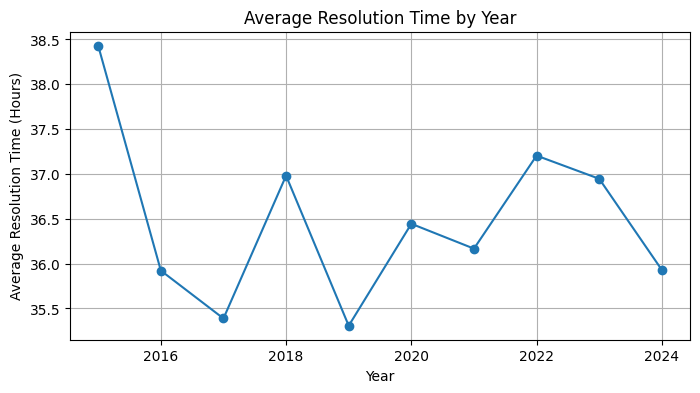

In [7]:
year_resolution = (
    df.groupby('Year')['Incident Resolution Time (in Hours)']
      .mean()
)

plt.figure(figsize=(8,4))
plt.plot(year_resolution.index,
         year_resolution.values,
         marker='o')

plt.title('Average Resolution Time by Year')
plt.xlabel('Year')
plt.ylabel('Average Resolution Time (Hours)')
plt.grid(True)
plt.show()

In [8]:
# Likelihood = seberapa sering kombinasi ini muncul di dataset
attack_likelihood = df.groupby(['Country', 'Attack Type', 'Target Industry', 'Security Vulnerability Type']).size().reset_index(name='count')

attack_likelihood['likelihood'] = attack_likelihood['count'] / len(df)

In [9]:
df_scaled = df_scaled.merge(
    attack_likelihood[
        ['Country', 'Attack Type', 'Target Industry', 'Security Vulnerability Type', 'likelihood']
    ],
    on=['Country', 'Attack Type', 'Target Industry', 'Security Vulnerability Type'],
    how='left'
)

#cek
df_scaled.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),impact_score,likelihood
0,China,2019,Phishing,Education,0.804402,0.773355,Hacker Group,Unpatched Software,VPN,0.873239,0.808856,0.000333
1,China,2019,Ransomware,Retail,0.620062,0.295770,Hacker Group,Unpatched Software,Firewall,0.985915,0.595945,0.000333
2,India,2017,Man-in-the-Middle,IT,0.383456,0.605949,Hacker Group,Weak Passwords,VPN,0.267606,0.427034,0.000667
3,UK,2024,Ransomware,Telecommunications,0.411499,0.659416,Nation-state,Social Engineering,AI-based Detection,0.084507,0.420476,0.001333
4,Germany,2018,Man-in-the-Middle,IT,0.742889,0.810898,Insider,Social Engineering,VPN,0.943662,0.803446,0.001333


In [10]:
print(len(df))
print(len(df_scaled))

3000
3000


In [11]:
df_scaled['risk_score'] = df_scaled['impact_score'] * df_scaled['likelihood']

df_scaled.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),impact_score,likelihood,risk_score
0,China,2019,Phishing,Education,0.804402,0.773355,Hacker Group,Unpatched Software,VPN,0.873239,0.808856,0.000333,0.000270
1,China,2019,Ransomware,Retail,0.620062,0.295770,Hacker Group,Unpatched Software,Firewall,0.985915,0.595945,0.000333,0.000199
2,India,2017,Man-in-the-Middle,IT,0.383456,0.605949,Hacker Group,Weak Passwords,VPN,0.267606,0.427034,0.000667,0.000285
3,UK,2024,Ransomware,Telecommunications,0.411499,0.659416,Nation-state,Social Engineering,AI-based Detection,0.084507,0.420476,0.001333,0.000561
4,Germany,2018,Man-in-the-Middle,IT,0.742889,0.810898,Insider,Social Engineering,VPN,0.943662,0.803446,0.001333,0.001071


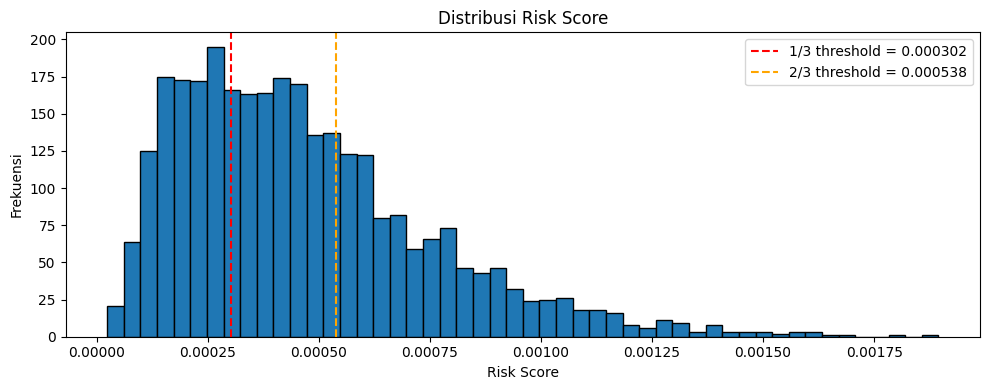

In [12]:
#Plot distribusi risk_score

# Hitung threshold di 1/3 dan 2/3 distribusi
t_1 = df_scaled['risk_score'].quantile(0.33)
t_2 = df_scaled['risk_score'].quantile(0.67)
    
# Plot distribusi
plt.figure(figsize=(10, 4))
plt.hist(df_scaled['risk_score'], bins=50, edgecolor='black')
plt.xlabel('Risk Score')
plt.ylabel('Frekuensi')
plt.title(f'Distribusi Risk Score')
plt.axvline(x=t_1, color='red', linestyle='--', label=f'1/3 threshold = {t_1:.6f}')
plt.axvline(x=t_2, color='orange', linestyle='--', label=f'2/3 threshold = {t_2:.6f}')
plt.legend()
plt.tight_layout()
plt.savefig(f"Distribusi Risk Score.png", dpi=300, bbox_inches='tight')
plt.show()

In [13]:
df_scaled['Risk Category'] = ''

for i in range(len(df_scaled)):
    
    score = df_scaled.loc[i, 'risk_score']

    if score <= 0.000302:
        df_scaled.loc[i, 'Risk Category'] = 'Low'

    elif score <= 0.000538:
        df_scaled.loc[i, 'Risk Category'] = 'Medium'

    else:
        df_scaled.loc[i, 'Risk Category'] = 'High'

df_scaled.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),impact_score,likelihood,risk_score,Risk Category
0,China,2019,Phishing,Education,0.804402,0.773355,Hacker Group,Unpatched Software,VPN,0.873239,0.808856,0.000333,0.000270,Low
1,China,2019,Ransomware,Retail,0.620062,0.295770,Hacker Group,Unpatched Software,Firewall,0.985915,0.595945,0.000333,0.000199,Low
2,India,2017,Man-in-the-Middle,IT,0.383456,0.605949,Hacker Group,Weak Passwords,VPN,0.267606,0.427034,0.000667,0.000285,Low
3,UK,2024,Ransomware,Telecommunications,0.411499,0.659416,Nation-state,Social Engineering,AI-based Detection,0.084507,0.420476,0.001333,0.000561,High
4,Germany,2018,Man-in-the-Middle,IT,0.742889,0.810898,Insider,Social Engineering,VPN,0.943662,0.803446,0.001333,0.001071,High


# Kesimpulan & Insight

## Tujuan EDA
Exploratory Data Analysis ini digunakan untuk menggali pola dan insight dari data serta melakukan feature engineering untuk Model Prediksi yaitu Klasifikasi dengan beberapa metode seperti XGBoost, Decision Tree, Random Calssifier, dan Light GBM. Klasifikasi ini akan memprediksi Kategori Resiko suatu Serangan (Low/Medium/High) berdasarkan Country, Attack Type, Target Industry, Financial Loss (in Million $), Number of Affected Users, Attack Source, Security Vulnerability Type, Defense Mechanism Used, Incident Resolution Time (in Hours)	

## Insight dari Data
1. Data asli memiliki 10 kolom yang mencakup: Country, Year, Attack Type, Target Industry, Financial Loss (in Million $), Number of Affected Users, Attack Source, Security Vulnerability Type, Defense Mechanism Used, Incident Resolution Time (in Hours) dan berdasarkan pengecekan awal data sudah bersih untuk dilakukan EDA
2. Pertama dilakukan eksplorasi terhadap distribusi kolom numerik yaitu Financial Loss, Number of Affected Users, dan Incident Resolution Time dan ditemukan seluruh kolom numerik berdistribusi uniform.
3. Kemudian dilakukan feature engineering yaitu melakukan MinMaxScaler pada seluruh kolom numerik (untuk menyamakan rentang nilai antar kolom numerik ke skala 0–1 tanpa mengubah bentuk distribusi aslinya) lalu membuat kolom impact_score = $0.5\times$ Financial Loss $+ 0.3 \times$ Number of Affected Users $+ 0.2 \times$ Incident Resolution Time.
4. Selanjutnya dilakukan eksplorasi distribusi fitur-fitur kategorik yang mencakup: Country, Attack Type, Target Industry, Attack Source, Security Vulnerability Type, Defense Mechanism Used; dari eksplorasi ini ditemukan distribusi tiap kolom cukup seimbang dengan selisih jumlah kelas terbesar dan terkecil < 100.
5. Kemudian dilakukan pengecekan time-series tahunan terkait Sum of Attacks dan Incident Resolution Time dimana tidak ada indikator khusus fitur Year berpengaruh terhadap pola serangan.
6. Dilakukan agregasi secara count untuk membentuk `attack_likelihood` yang merepresentasikan peluang munculnya suatu pola serangan berdasarkan kombinasi unik Country × Attack Type × Target Industry × Attack Source × Security Vulnerability Type. Pemilihan kelima fitur ini didasarkan pada perspektif penyerang (*attacker's perspective*) — Country mencerminkan asal dan target geografis, Attack Type mencerminkan metode yang digunakan, Target Industry mencerminkan sektor yang disasar, Attack Source mencerminkan vektor serangan, dan Security Vulnerability Type mencerminkan celah yang dieksploitasi. Likelihood dihitung sebagai frekuensi relatif (count/total rows) dari setiap kombinasi unik kelima fitur tersebut.
7. Selanjutnya dilakukan merge terhadap dataset.
8. Kemudian dilakukan penghitungan skor risiko dimana risk_score = impact_score $\times$ likelihood dan visualisasi distribusinya serta batas kuantil 1/3 dan 2/3. Pembagian berdasarkan quantile dipilih untuk memastikan distribusi label Low/Medium/High yang seimbang (~33% tiap kelas), yang penting untuk training model klasifikasi, sehingga label Low, Medium, High diberikan berdasarkan pembagian merata risk_score.


In [14]:
df_scaled.to_csv('clean_data.csv', index=False)